In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Iris.csv")

In [3]:
df=df.dropna()
df.isna().sum()
df=df.drop('Id',axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
2,5.0,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa


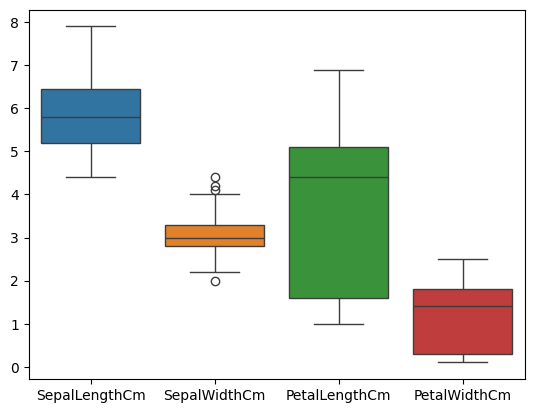

In [5]:
sns.boxplot(data=df)
plt.show()

In [6]:
import numpy as np
q1 = df['SepalWidthCm'].quantile(0.25)
q3 = df['SepalWidthCm'].quantile(0.75)
IQR = q3-q1

lb = q1-1.5*IQR
ub = q3+1.5*IQR
df['SepalWidthCm']=np.where(df['SepalWidthCm']>ub,ub,df['SepalWidthCm'])
df['SepalWidthCm']=np.where(df['SepalWidthCm']<lb,lb,df['SepalWidthCm'])

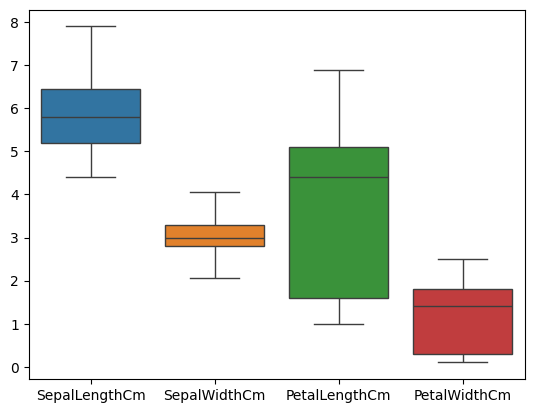

In [7]:
sns.boxplot(data = df)
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Species'] = le.fit_transform(df['Species'])
df['Species'].value_counts()

Species
2    48
1    47
0    40
Name: count, dtype: int64

In [9]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

x = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df[['Species']]

gauss = GaussianNB()

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2)
gauss.fit(xtrain, ytrain)

/home/nitish/.local/share/pipx/venvs/notebook/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [10]:

gauss.score(xtest, ytest)

0.9629629629629629

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
cm = confusion_matrix(y_true = ytest, y_pred = gauss.predict(xtest))

print("Confusion Matrix :\n", cm)

Confusion Matrix :
 [[8 0 0]
 [0 9 1]
 [0 0 9]]


In [12]:
y_pred = gauss.predict(xtest)

accuracy = accuracy_score(ytest, y_pred)
precision = precision_score(ytest, y_pred, average='macro')
recall = recall_score(ytest, y_pred, average='macro')
error_rate = 1 - accuracy

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)


Accuracy: 0.9629629629629629
Error Rate: 0.03703703703703709
Precision: 0.9666666666666667
Recall: 0.9666666666666667


<Axes: >

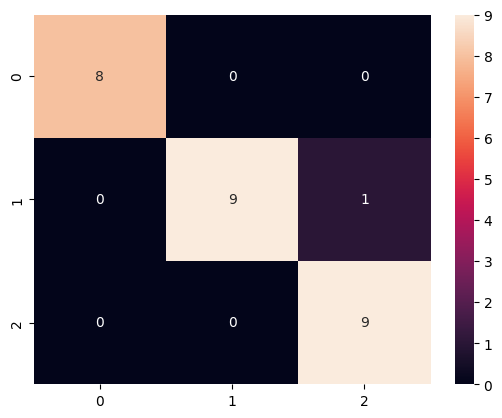

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(ytest, y_pred)
sns.heatmap(cm, annot=True)